In [40]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np
from scipy.stats import skewnorm

import cartopy.crs as ccrs



In [41]:
is_local_data = False
Month_idx = 4
safe = False
start = None
end = None
max_depth = 3

### Load parameters of the transformations

In [42]:
transform_keys = ["none","log","logit","rel"]

In [43]:
parameter_sets = {}
for key in transform_keys:
    parameter_sets[f"{key}_transform"] = model.loading.load_params(var = "mrsol",scen= "historical", folder = f"MPI-ESM1-2-LR/variations/Transformation_Distribution/{key}_transform/local{is_local_data}/month{Month_idx}", name=f"start={start},end={end}.max_depth{max_depth}")

the mask should only change if one is based on relative data, and one is abs because the threshold has a diffrent effect

In [44]:
print(parameter_sets["logit_transform"]["detail_mask"].equals(parameter_sets["rel_transform"]["detail_mask"]))
print(parameter_sets["none_transform"]["detail_mask"].equals(parameter_sets["log_transform"]["detail_mask"]))

True
True


In [45]:
print(parameter_sets["none_transform"]["chunk_mask"].equals(parameter_sets["log_transform"]["chunk_mask"]))
print(parameter_sets["none_transform"]["chunk_mask"].equals(parameter_sets["logit_transform"]["chunk_mask"]))
print(parameter_sets["none_transform"]["chunk_mask"].equals(parameter_sets["rel_transform"]["chunk_mask"]))


True
True
True


In [46]:
(parameter_sets["rel_transform"]["chunk_mask"]).sum()

<xarray.Dataset> Size: 8B
Dimensions:  ()
Data variables:
    mrsol    int64 8B 2935

In [47]:
chunk_mask = parameter_sets["none_transform"]["chunk_mask"]
abs_detal_mask = parameter_sets["none_transform"]["detail_mask"]
rel_detal_mask = parameter_sets["rel_transform"]["detail_mask"]

### Load test input and target

In [48]:
run_idx = 4
raw_mrsol_for_test = model.loading.load_data_set(var = "mrsol", local = is_local_data, run_idx=run_idx)

tas_ds = model.loading.load_data_set(var = "tas", local = is_local_data, run_idx=run_idx)
pr_ds = model.loading.load_data_set(var = "pr", local = is_local_data, run_idx=run_idx)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=Month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=Month_idx)

raw_input_for_test = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### shape inputs

In [49]:
def shape_input(ds, chunk_mask):
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx)
    ds = model.mask.mask_mask(ds,chunk_mask)
    ds = mesmer.grid.stack_lat_lon(ds)
    return ds


In [50]:
inputs = {}
for key in transform_keys:
    inputs[key] = shape_input(raw_input_for_test, parameter_sets[f"{key}_transform"]["chunk_mask"].mrsol)

### shape targets

In [51]:
def shape_target(ds):
    #ds = ds.clip(min = 1e-32)
    ds = ds.sel(time=slice(start, end)).resample(time="ME").mean()
    ds = ds.sel(time= ds.time.dt.month == Month_idx).isel(depth=slice(0, max_depth)).drop_vars("depth_bnds")
    return ds

In [52]:
def mask_stack_target(ds):
    masked_ds, chunk_mask, detail_mask= model.mask.mask_nonpositiv_height_chunks(ds)
    ds = mesmer.grid.stack_lat_lon(masked_ds)
    ds = ds.transpose("gridcell","time", "depth")
    return ds

In [53]:
targets= {}

none transform

In [54]:
target_unstacked = shape_target(raw_mrsol_for_test)
target = mask_stack_target(target_unstacked)

glaub unnötig
rel transform
maximas = parameter_sets["rel_transform"]["local_maximas"]
rel_target = raw_mrsol_for_test/maximas
rel_target = shape_target(rel_target)
targets["rel"] = mask_stack_target(rel_target)

Log transform
log_target = shape_target(raw_mrsol_for_test)
log_target = mask_stack_target(log_target)
targets["log"] = model.transform.Log_Transform_ds(log_target)
Logit transform
maximas = parameter_sets["logit_transform"]["local_maximas"]
logit_target = raw_mrsol_for_test/maximas
logit_target = shape_target(logit_target)
logit_target = mask_stack_target(logit_target)
targets["logit"] = model.transform.Logit_Transform_ds(logit_target)

### Emulate

In [55]:
predictions = {}

In [56]:
for t_key in transform_keys:
    for m_key in ["mean","variance","skew"]:
        if m_key == "skew" and t_key in ["none", "rel"]:
            break
        LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
        LinReg = LinReg.from_params(parameter_sets[f"{t_key}_transform"][m_key])
        if m_key == "skew":
            predictions[f"{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth").clip(min=-0.995,max=0.995)
        if m_key == "variance":
            predictions[f"{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth").clip(min=1e-32)
        else:
            predictions[f"{t_key}_{m_key}"] = LinReg.predict(inputs[t_key]).transpose("gridcell","time", "depth")

maximas

In [57]:
rel_maximas_da = model.mask.mask_mask(parameter_sets["rel_transform"]["local_maximas"],parameter_sets["rel_transform"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
rel_maximas_da = mesmer.grid.stack_lat_lon(rel_maximas_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol

logit_maximas_da = model.mask.mask_mask(parameter_sets["logit_transform"]["local_maximas"],parameter_sets["logit_transform"]["chunk_mask"].mrsol).isel(depth=slice(0, max_depth))
logit_maximas_da = mesmer.grid.stack_lat_lon(logit_maximas_da).drop_vars("depth_bnds").transpose("gridcell","depth").mrsol


#### Scores

In [58]:
score_sets = {}


In [59]:
score_keys = ["beta","gamma","norm_log","norm_logit","skew_log","skew_logit","cringe"]

beta

In [60]:
score_sets["cringe"] = model_analysis.crps_score.crps_norm_score(predictions["none_mean"],predictions["none_variance"], target, transformation = None, ensemble_size = 15)

In [61]:
score_sets["beta"] = model_analysis.crps_score.crps_beta_score(predictions["rel_mean"],predictions["rel_variance"], target, transformation = "rel", maximas_da = rel_maximas_da,ensemble_size = 15)

In [62]:
score_sets["gamma"] = model_analysis.crps_score.crps_gamma_score(predictions["none_mean"].clip(min = 1e-32),predictions["none_variance"], target, transformation = None, ensemble_size = 15)

In [63]:
score_sets["norm_log"] = model_analysis.crps_score.crps_norm_score(predictions["log_mean"],predictions["log_variance"], target, transformation = "Log", ensemble_size = 15)

In [64]:
score_sets["norm_logit"] = model_analysis.crps_score.crps_norm_score(predictions["logit_mean"],predictions["logit_variance"], target, transformation = "Logit", maximas_da = logit_maximas_da,ensemble_size = 15)

In [65]:
score_sets["skew_log"] = model_analysis.crps_score.crps_skew_score(predictions["log_mean"],predictions["log_variance"],predictions["log_skew"], target, transformation = "Log",ensemble_size = 15)

In [66]:
score_sets["skew_logit"] = model_analysis.crps_score.crps_skew_score(predictions["logit_mean"],predictions["logit_variance"],predictions["logit_skew"], target, transformation = "Logit",maximas_da = logit_maximas_da,ensemble_size = 15)

In [67]:
for s_keys, scores in score_sets.items():
    score_sets[s_keys] = mesmer.grid.unstack_lat_lon_and_align(scores, target_unstacked)
    if s_keys in ["beta","norm_logit","skew_logit"]:
        score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],rel_detal_mask.mrsol,"lon", "lat", "depth")
    else:
        score_sets[s_keys] = model.mask.mask_mask(score_sets[s_keys],abs_detal_mask.mrsol,"lon", "lat", "depth")

In [68]:
all_scores_ds =xr.Dataset({key : score.crps_score for key, score in score_sets.items()})

In [78]:
all_scores_ds.mean(dim=["lon","lat","time"])

<xarray.Dataset> Size: 192B
Dimensions:     (depth: 3)
Coordinates:
  * depth       (depth) float64 24B 0.03 0.19 0.78
Data variables:
    cringe      (depth) float64 24B 0.4259 1.658 6.772
    beta        (depth) float64 24B 0.4273 1.658 6.751
    gamma       (depth) float64 24B 0.4259 1.659 6.777
    norm_log    (depth) float64 24B 0.4496 1.672 6.8
    norm_logit  (depth) float64 24B 0.4179 1.643 6.723
    skew_log    (depth) float64 24B 0.4508 1.676 6.798
    skew_logit  (depth) float64 24B 0.42 1.648 6.744

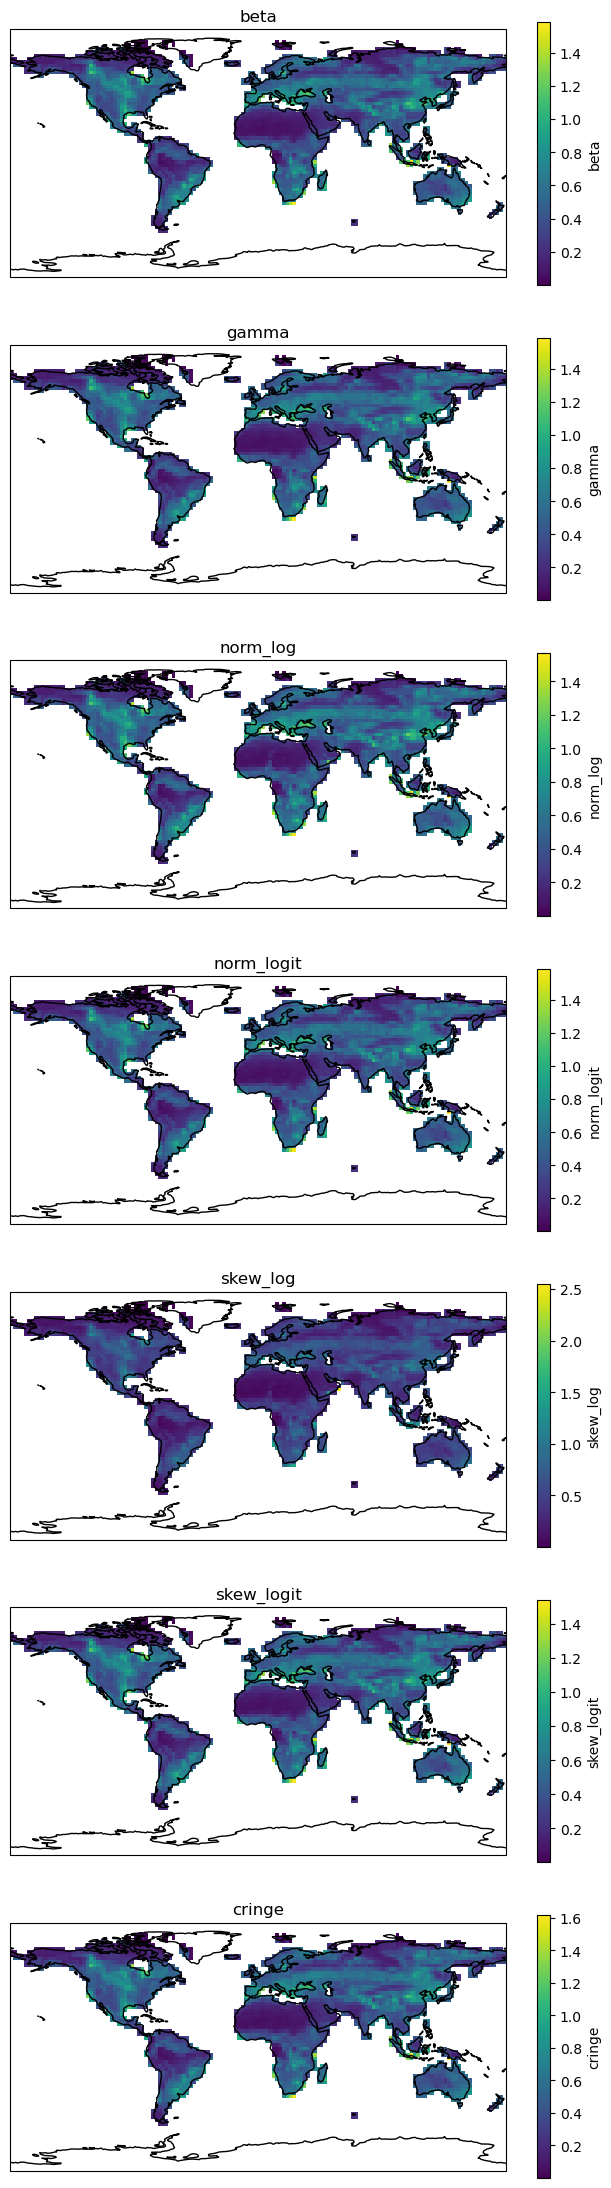

In [69]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=7,
    ncols=1,
    figsize=(8, 28)
)
depth = 0

for i, s_key in enumerate(score_keys):
    da = all_scores_ds.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[i])
    ax[i].coastlines()
    ax[i].set_title(s_key)



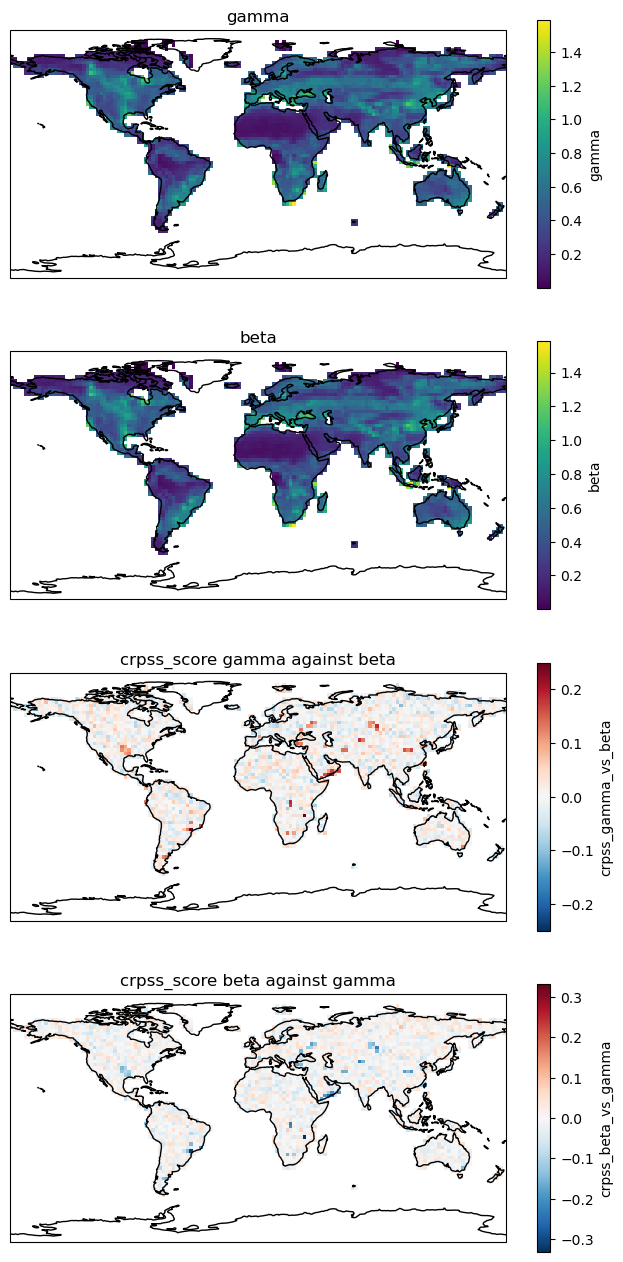

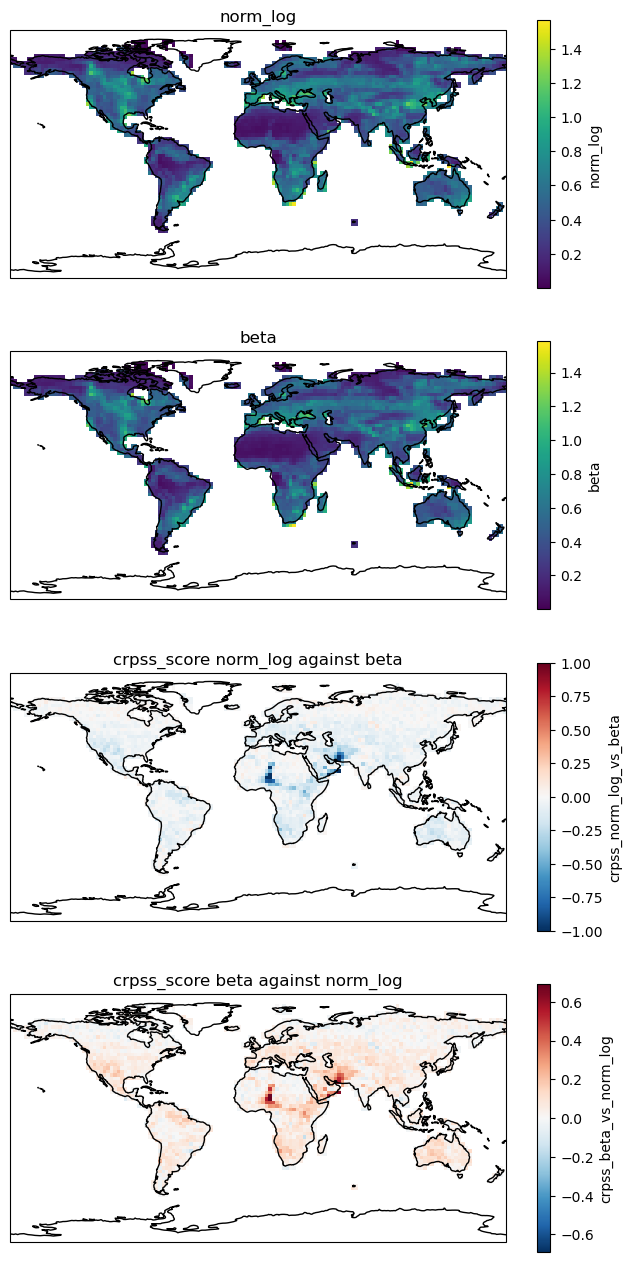

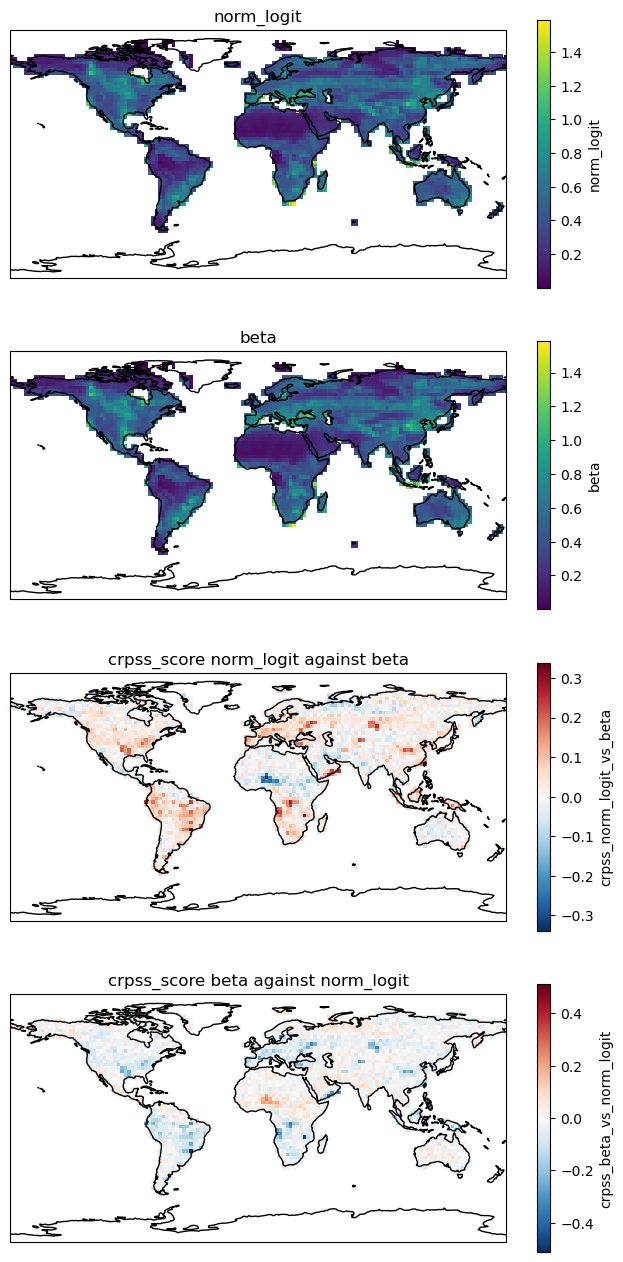

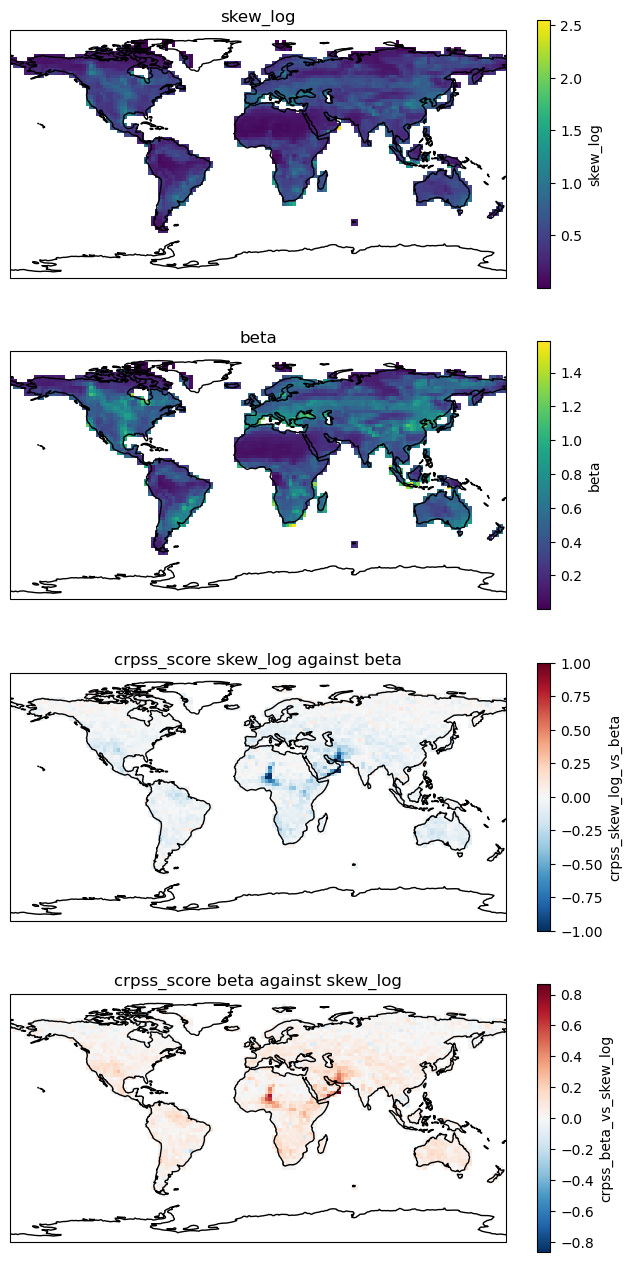

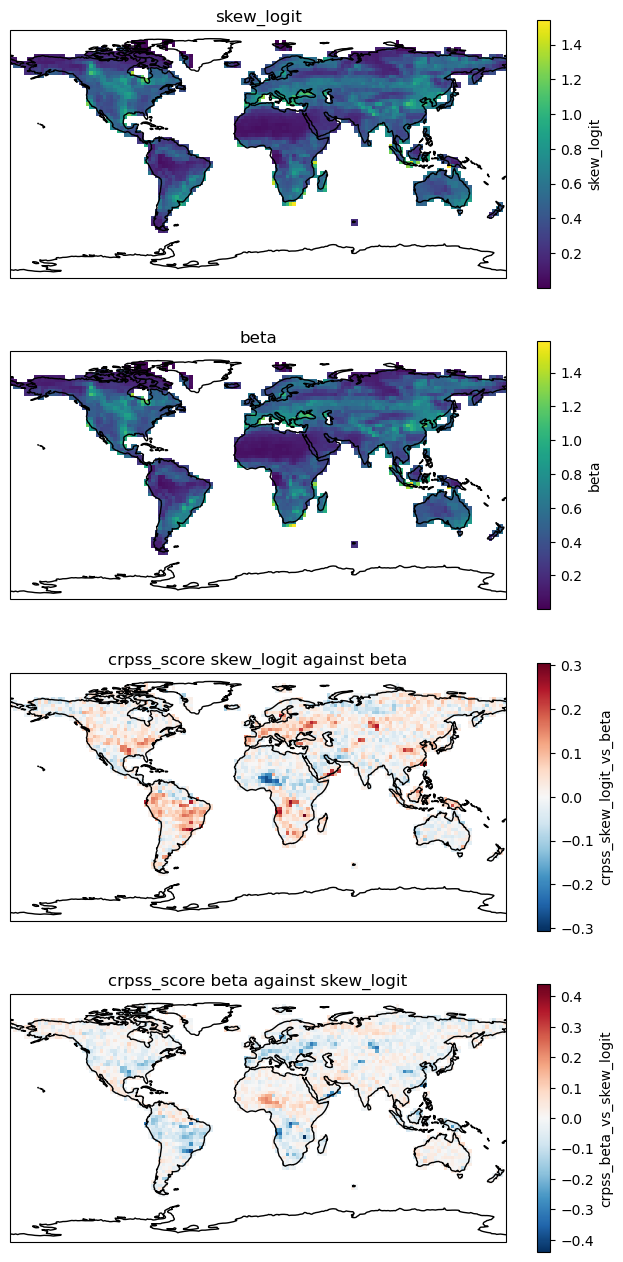

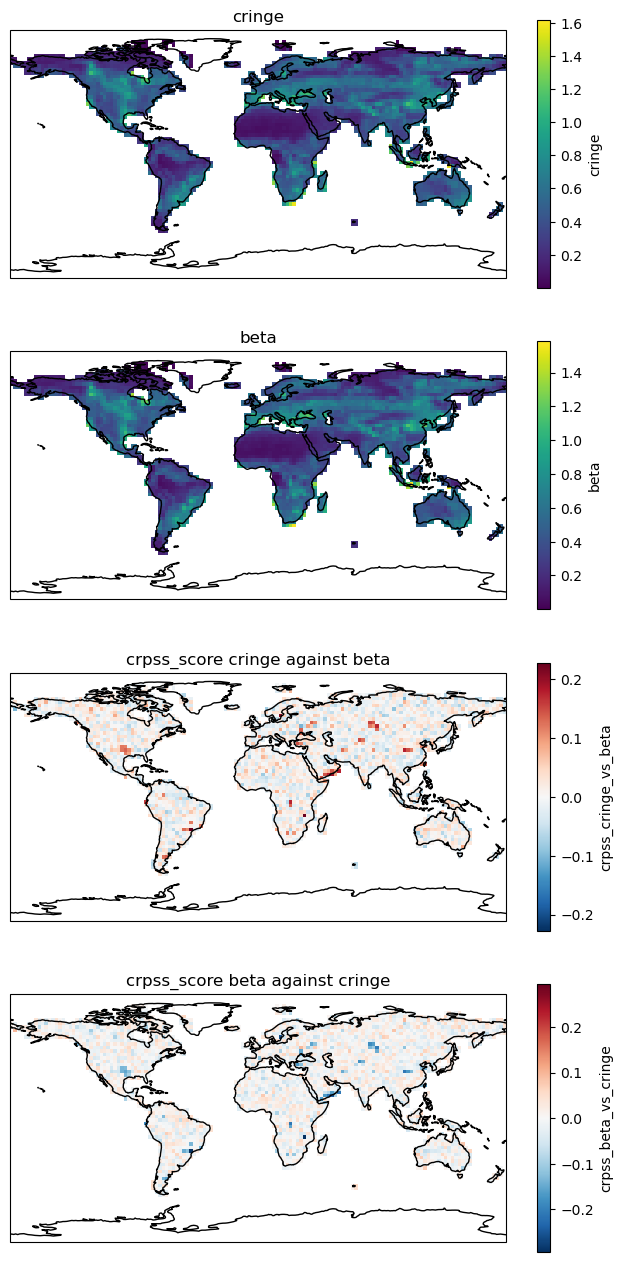

In [70]:
depth = 0

for i, s_key in enumerate(score_keys):
    if s_key == "beta":
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets["beta"].crps_score,score_sets[s_key].crps_score,"beta",s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
    )
    
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time").beta
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title("beta")

    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_beta"].clip(min=-1)
    da.plot(ax=ax[2])
    ax[2].coastlines()
    ax[2].set_title(f"crpss_score {s_key} against beta")

    da = vs.isel(depth=depth)[f"crpss_beta_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[3])
    ax[3].coastlines()
    ax[3].set_title(f"crpss_score beta against {s_key}")

    fig_global_crpss.show()
    


In [79]:
score_keys

['beta', 'gamma', 'norm_log', 'norm_logit', 'skew_log', 'skew_logit', 'cringe']

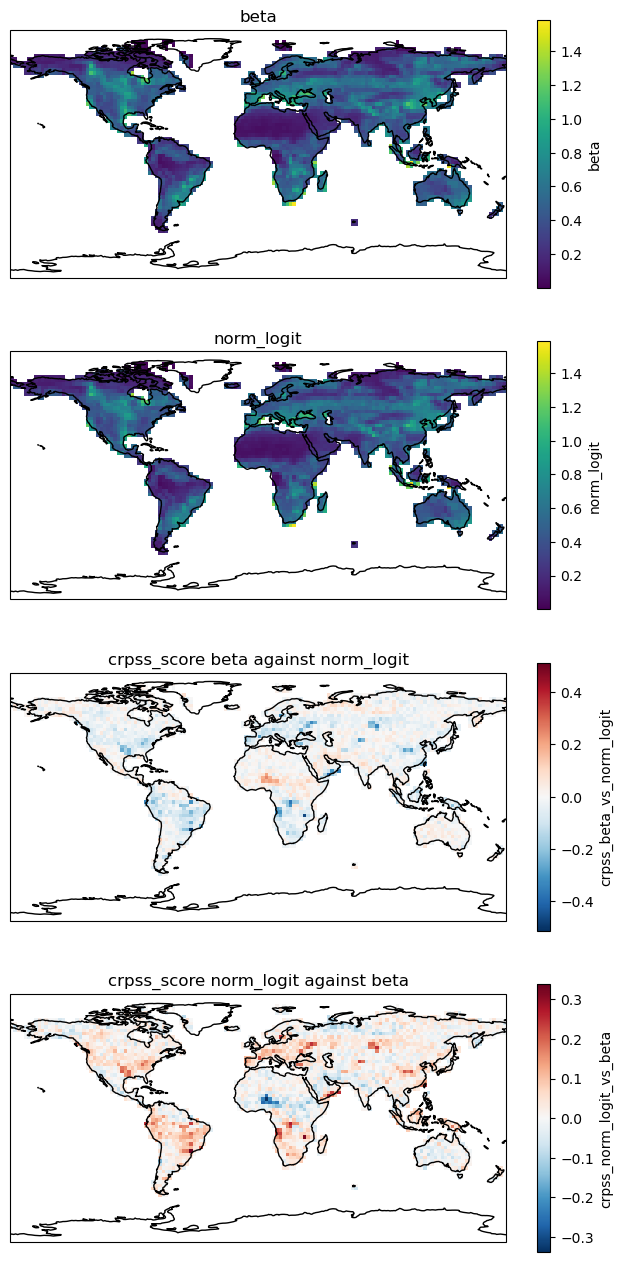

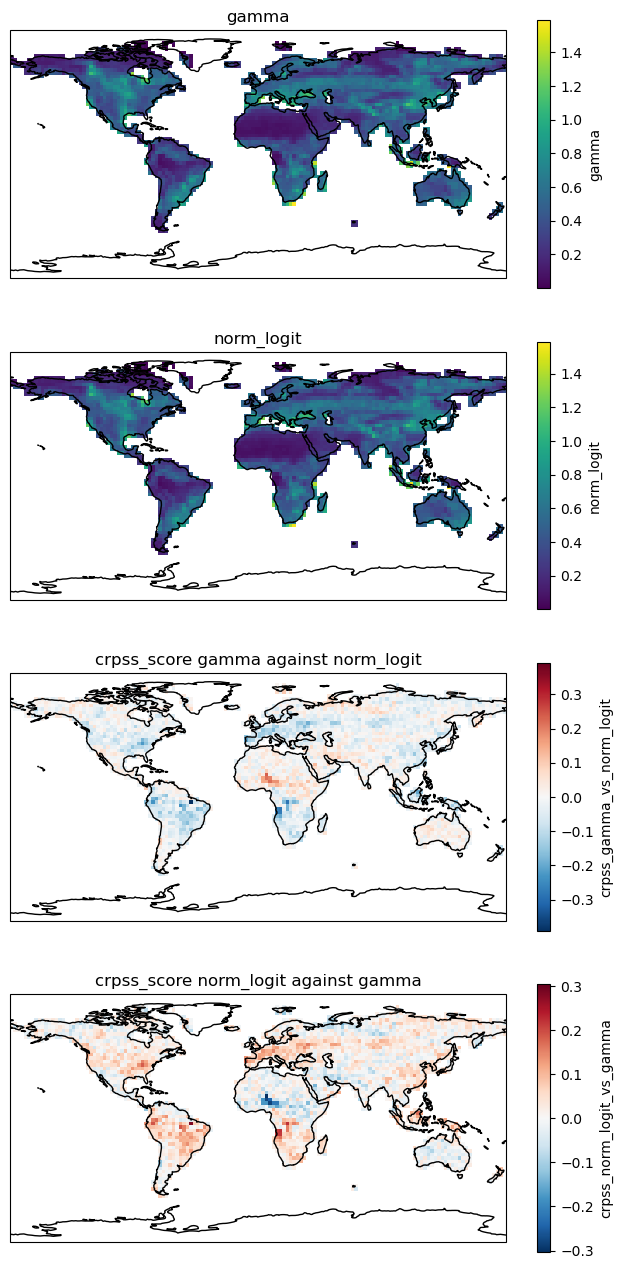

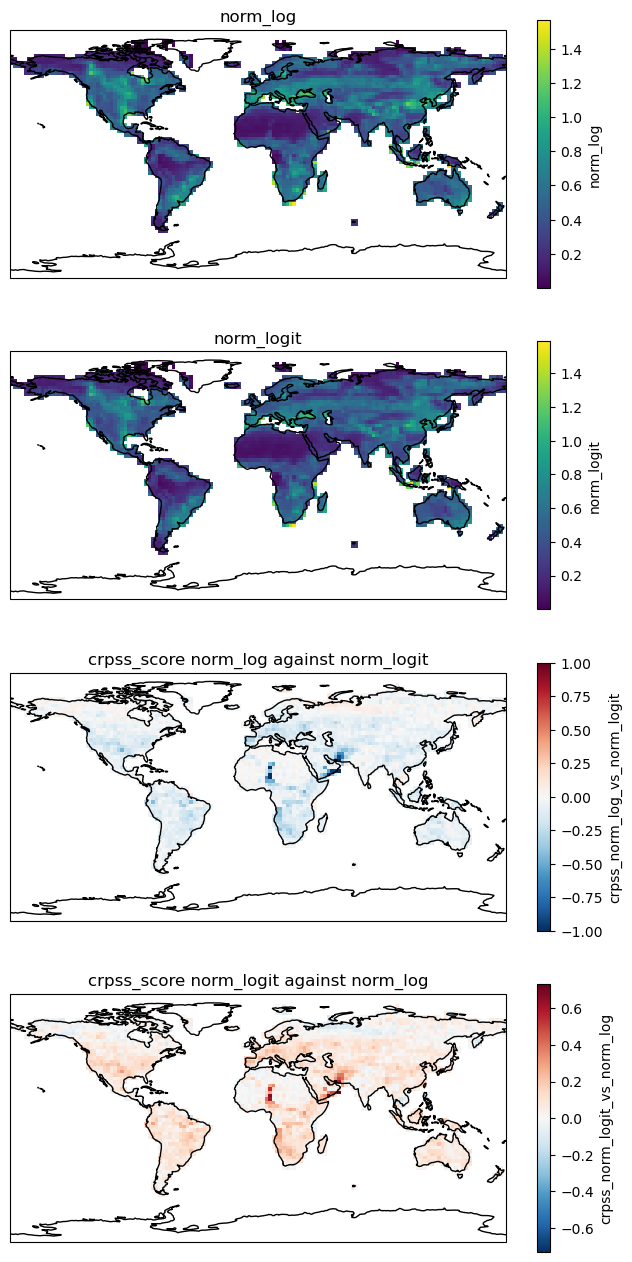

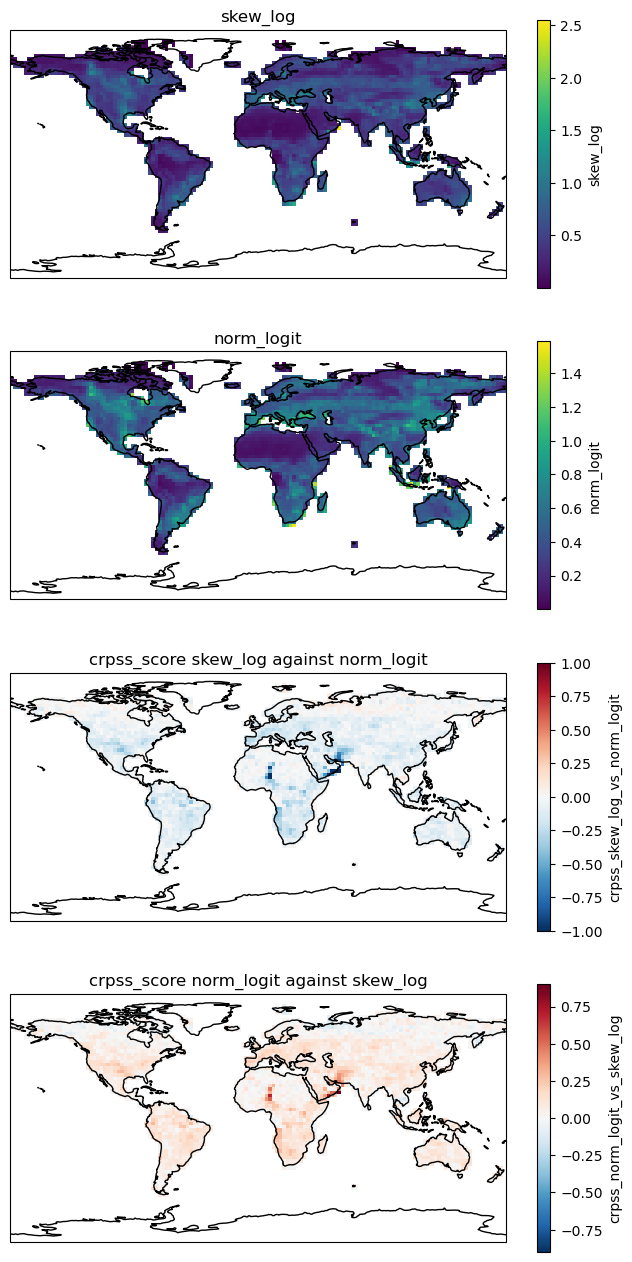

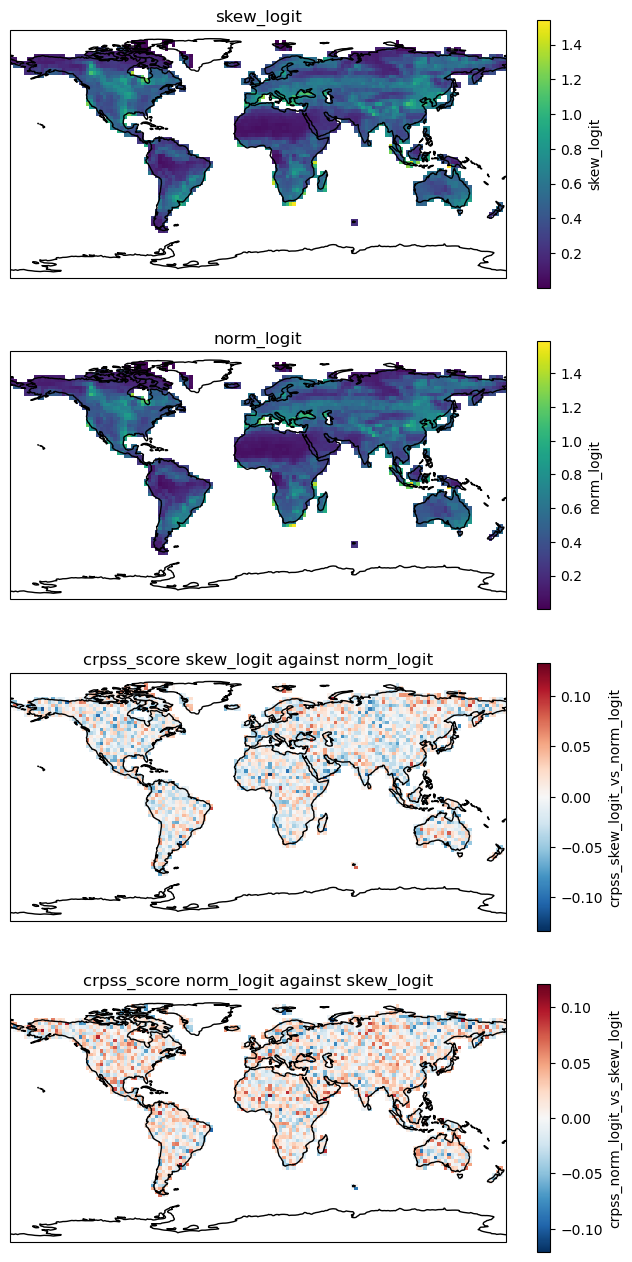

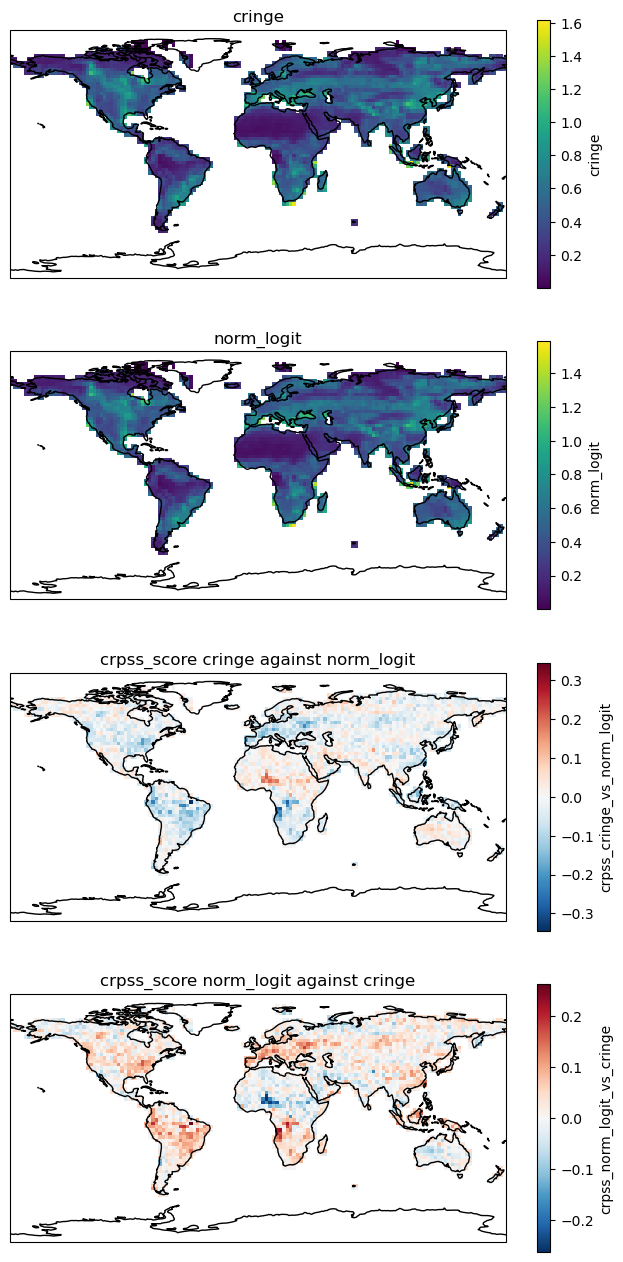

In [80]:
depth = 0

for i, s_key in enumerate(score_keys):
    if s_key == "norm_logit":
        continue
    vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets["norm_logit"].crps_score,score_sets[s_key].crps_score,"norm_logit",s_key)

    fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
    )
    
    da = vs.isel(depth=depth).mean("time")[s_key]
    da.plot(ax=ax[0])
    ax[0].coastlines()
    ax[0].set_title(s_key)

    da = vs.isel(depth=depth).mean("time").norm_logit
    da.plot(ax=ax[1])
    ax[1].coastlines()
    ax[1].set_title("norm_logit")

    da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_norm_logit"].clip(min=-1)
    da.plot(ax=ax[2])
    ax[2].coastlines()
    ax[2].set_title(f"crpss_score {s_key} against norm_logit")

    da = vs.isel(depth=depth)[f"crpss_norm_logit_vs_{s_key}"].clip(min=-1)
    da.plot(ax=ax[3])
    ax[3].coastlines()
    ax[3].set_title(f"crpss_score norm_logit against {s_key}")

    fig_global_crpss.show()
    


In [71]:
emp = scores_beta_approx_emp11 = model.loading.load_scores(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist",name=f"approx_emp11_month_idx = {4}", name_postfix="back_transformed")

In [72]:
gamma_ext = model.loading.load_scores(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/gamma", name=f"month_idx = {4}",name_postfix="")

In [73]:
emp

<xarray.Dataset> Size: 55MB
Dimensions:             (depth: 2, time: 165, lat: 72, lon: 144)
Coordinates:
  * depth               (depth) float64 16B 0.03 0.19
  * time                (time) datetime64[ns] 1kB 1850-04-30 ... 2014-04-30
  * lat                 (lat) float64 576B -88.75 -86.25 -83.75 ... 86.25 88.75
  * lon                 (lon) float64 1kB 1.25 3.75 6.25 ... 353.8 356.2 358.8
Data variables:
    crps_score          (depth, time, lat, lon) float64 27MB nan nan ... nan nan
    const_mean_crps     (time, depth, lat, lon) float64 27MB nan nan ... nan nan
    crpss_against_mean  (depth, lat, lon) float64 166kB nan nan nan ... nan nan

In [74]:
vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets["gamma"].crps_score.isel(depth=slice(0,2)),gamma_ext.crps_score,"gamma","gamma_ext")

/home/pjunghans/BachelorArbeit/model_analysis/crps_score.py:537: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  combined_crps = xr.concat([crps_score_1, crps_score_2], dim="model")


In [75]:
vs = model_analysis.crps_score.combine_two_crps_and_the_crpss(score_sets["beta"].crps_score.isel(depth=slice(0,2)),emp.crps_score,"beta","emp")

In [76]:
s_key = "gamma_ext"

KeyError: "No variable named 'gamma_ext'. Variables on the dataset include ['lon', 'lat', 'depth', 'beta', 'emp', 'crpss_beta_vs_emp', 'crpss_emp_vs_beta']"

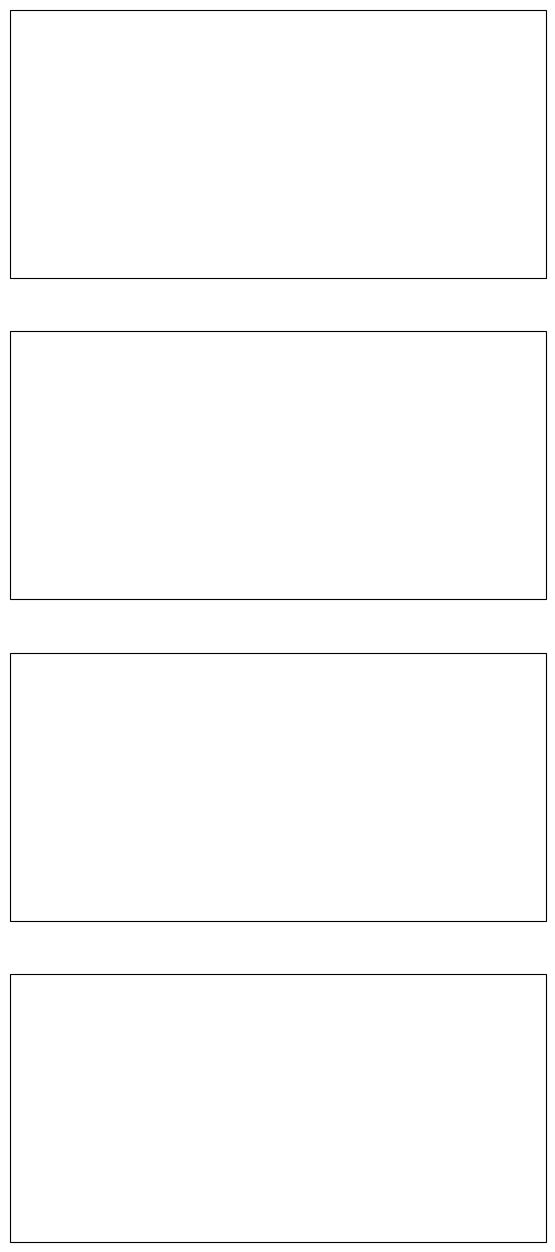

In [77]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
    )

da = vs.isel(depth=depth).mean("time")[s_key]
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title(s_key)

da = vs.isel(depth=depth).mean("time").beta
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("beta")

da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_beta"].clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title(f"crpss_score {s_key} against beta")

da = vs.isel(depth=depth)[f"crpss_beta_vs_{s_key}"].clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title(f"crpss_score beta against {s_key}")

fig_global_crpss.show()
    

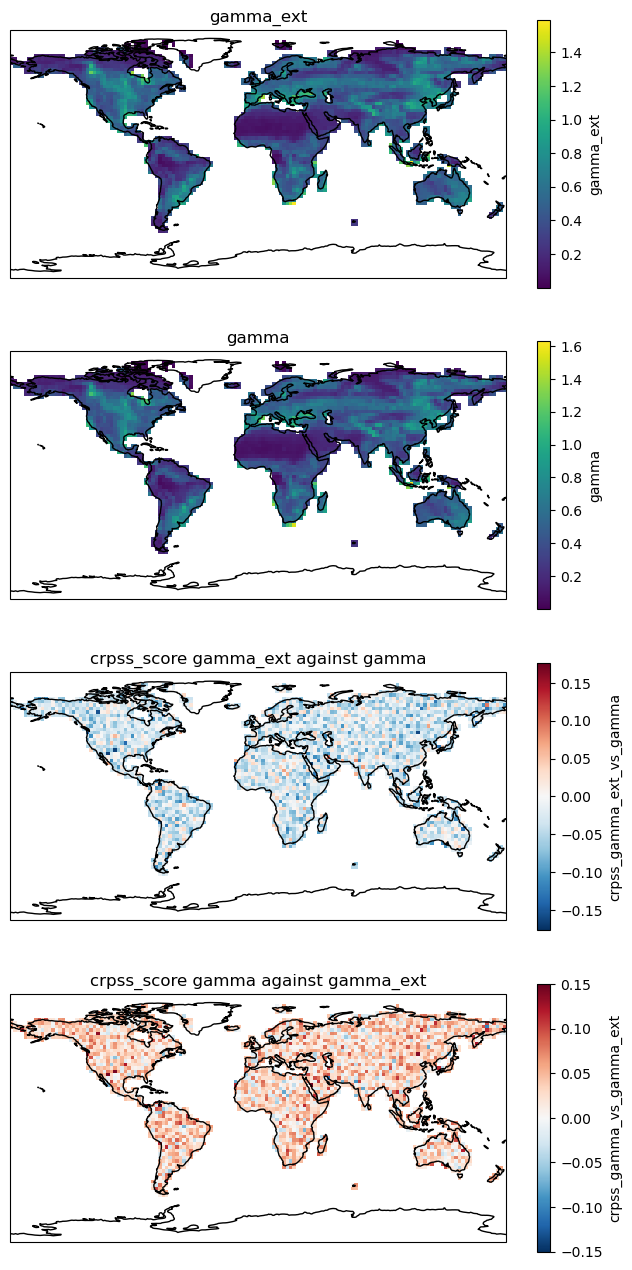

In [ ]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=4,
    ncols=1,
    figsize=(8, 16)
    )

da = vs.isel(depth=depth).mean("time")[s_key]
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title(s_key)

da = vs.isel(depth=depth).mean("time").gamma
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("gamma")

da = vs.isel(depth=depth)[f"crpss_{s_key}_vs_gamma"].clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title(f"crpss_score {s_key} against gamma")

da = vs.isel(depth=depth)[f"crpss_gamma_vs_{s_key}"].clip(min=-1)
da.plot(ax=ax[3])
ax[3].coastlines()
ax[3].set_title(f"crpss_score gamma against {s_key}")

fig_global_crpss.show()
    

In [ ]:
lul

NameError: name 'lul' is not defined

In [ ]:
for s_key in score_keys:
    score_sets[s_key] = score_sets[s_key].assign_coords({"score_type":s_key})

In [ ]:
delta = np.sqrt(np.pi*(skew**(2/3))/(2*((skew**(2/3))+(2-np.pi/2)**(2/3))))

alpha = delta/np.sqrt(1-delta**2) #shape
omega = np.sqrt(var/(1-2*delta**2/np.pi)) #scale
xi  = mean - omega * delta *np.sqrt(2/np.pi) #location

